# Recommender System + Marketplace Health Compare

This notebook keeps the original training and model code unchanged, then adds a compact marketplace-health comparison section.

What is kept:
- Same data paths as `recsys_5_fixed.ipynb`.
- Same candidate generation code.
- Same LightGBM training code and parameters.
- Same validation objects produced by the original pipeline.

What is removed:
- Schema inspection cells.
- Final test scoring/export section.

The goal is a clean report notebook: original model as baseline, one market-health reranker, and a what-if table showing how much Recall changes when the health constraint strength changes.


## 0) Original Model Is Preserved

The following code cells are copied from `recsys_5_fixed.ipynb` without editing their source. The marketplace-health logic at the end is post-processing only: it uses the model score already produced by the original LightGBM ranker.

This means the best-performing model remains the base model. The extra section only demonstrates that the team considered marketplace health and can control the trade-off between Recall/NDCG and freshness, diversity, fairness, and coverage.


In [1]:
import os
import duckdb

# Base path
BASE_DATA_DIR = r"d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\datathon_2026_processed"

# Pathways
PATHS = {
    "dim_listing": os.path.join(BASE_DATA_DIR, "train_clean", "dim_listing", "dim_listing_cleaned.parquet"),
    "fact_listing": os.path.join(BASE_DATA_DIR, "train_clean", "fact_listing_snapshot", "fact_listing_snapshot_cleaned.parquet"),
    "user_ad_interactions": os.path.join(BASE_DATA_DIR, "train_clean", "fact_user_ad_interactions", "*.parquet"),
    "user_events": os.path.join(BASE_DATA_DIR, "train_clean", "fact_user_events", "**", "*.parquet"),
    "test_users": os.path.join(BASE_DATA_DIR, "test", "test_users.parquet"),
}

# Initialize DuckDB connection
con = duckdb.connect(database=":memory:")
print("DuckDB initialized.")

DuckDB initialized.


In [2]:
from datetime import date, timedelta
import os
import numpy as np
import pandas as pd

#  Time Windows 
CUTOFF_DATE   = date(2026, 4, 9)          # Absolute data boundary (no data after this)

# Feature cutoff: features are computed up to this date (no leakage)
FEATURE_CUTOFF = date(2026, 3, 9)         # Last day for training features

# Training label window
TRAIN_END   = FEATURE_CUTOFF              # = 2026-03-09
TRAIN_START = TRAIN_END - timedelta(days=29)  # = 2026-02-08

# Validation label window (unseen future relative to features)
VAL_START = date(2026, 3, 10)
VAL_END   = CUTOFF_DATE                   # = 2026-04-09

LAST_7D_START  = FEATURE_CUTOFF - timedelta(days=6)
LAST_30D_START = FEATURE_CUTOFF - timedelta(days=29)

PRED_START = date(2026, 4, 10)
PRED_END   = date(2026, 5, 7)

POSITIVE_EVENTS = [
    "view_phone",
    "contact_chat",
    "other_interaction",
    "contact_zalo",
    "contact_sms",
]

#  Candidate generation flags 
ENABLE_I2I = True   # Item-to-item co-occurrence candidates (recommended)
ENABLE_ALS = True   # ALS collaborative filtering candidates
I2I_WINDOW = 3      # Session co-occurrence window size
ALS_RECOMMEND_N = 51  # Slight recall lift: +1 ALS candidate/user, controlled pool growth
TARGET_CANDIDATE_POOL_ROWS = 57_120_000  # Final thin recall boost target
RECALL_BOOST_ITEM_LIMIT = 500            # Over-generate so anti-join can find unseen items

#  Cache / DuckDB settings 
CACHE_DIR = os.path.join(os.path.dirname(BASE_DATA_DIR), "save_parquet")
TEMP_DIR  = os.path.join(CACHE_DIR, "duckdb_temp")
os.makedirs(TEMP_DIR, exist_ok=True)

con.execute("SET memory_limit = '12GB'")
con.execute("PRAGMA threads = 4")
con.execute("SET preserve_insertion_order = false")
try:
    con.execute(f"PRAGMA temp_directory = '{TEMP_DIR}'")
except Exception:
    pass
con.execute("PRAGMA enable_profiling = 'no_output'")

DEV_SAMPLE           = False
DEV_SAMPLE_PCT       = 100
DEV_USER_SAMPLE_PCT  = 100
DEV_ITEM_SAMPLE_PCT  = 100
DEV_ITEM_POP_LIMIT   = 5000
DEV_DAYS             = 30
DEV_START            = CUTOFF_DATE - timedelta(days=DEV_DAYS - 1)

USE_CACHE = True  # Set to True to enable caching of intermediate results as Parquet files

events_sample_clause   = f"TABLESAMPLE BERNOULLI ({DEV_SAMPLE_PCT} PERCENT)" if DEV_SAMPLE else ""
events_filter_clause   = f"WHERE date >= DATE '{DEV_START}'" if DEV_SAMPLE else ""
snapshot_filter_clause = f"WHERE CAST(date AS DATE) >= DATE '{DEV_START}'" if DEV_SAMPLE else ""
user_pref_filter_clause = f"WHERE random() < {DEV_USER_SAMPLE_PCT / 100}" if DEV_SAMPLE else ""
item_sample_clause     = f"TABLESAMPLE BERNOULLI ({DEV_ITEM_SAMPLE_PCT} PERCENT)" if DEV_SAMPLE else ""
item_pop_limit_clause  = f"ORDER BY total_contacts DESC LIMIT {DEV_ITEM_POP_LIMIT}" if DEV_SAMPLE else ""

# Register Parquet datasets as DuckDB views
con.execute(f"""CREATE OR REPLACE VIEW dim_listing AS
SELECT * FROM read_parquet('{PATHS['dim_listing']}')""")
con.execute(f"""CREATE OR REPLACE VIEW fact_listing_snapshot AS
SELECT * FROM read_parquet('{PATHS['fact_listing']}') {snapshot_filter_clause}""")
con.execute(f"""CREATE OR REPLACE VIEW fact_user_ad_interactions AS
SELECT * FROM read_parquet('{PATHS['user_ad_interactions']}')""")
con.execute(f"""CREATE OR REPLACE VIEW fact_user_events AS
SELECT * FROM read_parquet('{PATHS['user_events']}') {events_sample_clause} {events_filter_clause}""")
con.execute(f"""CREATE OR REPLACE VIEW test_users AS
SELECT * FROM read_parquet('{PATHS['test_users']}')""")

# Register fact_post_contact_interactions if it exists
_pci_path = os.path.join(os.path.dirname(PATHS['user_ad_interactions'].replace('*.parquet', '')),
                         '..', 'fact_post_contact_interactions', '*.parquet')
_pci_path = os.path.normpath(_pci_path)
if os.path.exists(os.path.dirname(_pci_path)):
    try:
        con.execute(f"""CREATE OR REPLACE VIEW fact_post_contact_interactions AS
        SELECT * FROM read_parquet('{_pci_path}')""")
        HAS_PCI = True
        print("fact_post_contact_interactions registered.")
    except Exception as _e:
        HAS_PCI = False
        print(f"fact_post_contact_interactions not available: {_e}")
else:
    HAS_PCI = False
    print("fact_post_contact_interactions path not found â€” lead velocity feature will be skipped.")

print("DuckDB views registered.")
test_users = pd.read_parquet(PATHS["test_users"])
print("test_users loaded as DataFrame.")
print(f"FEATURE_CUTOFF={FEATURE_CUTOFF} | TRAIN={TRAIN_START}..{TRAIN_END} | VAL={VAL_START}..{VAL_END}")


fact_post_contact_interactions path not found â€” lead velocity feature will be skipped.
DuckDB views registered.
test_users loaded as DataFrame.
FEATURE_CUTOFF=2026-03-09 | TRAIN=2026-02-08..2026-03-09 | VAL=2026-03-10..2026-04-09


## 1) Feature Aggregates

Build user, item, preference, and user-item aggregates with the same logic as the original notebook.


In [3]:
# Create target users table (union of test users + 30k sampled training users)
# NOTE: All feature aggregations use FEATURE_CUTOFF to prevent data leakage.
print("Creating target users candidate pool...")
con.execute("DROP TABLE IF EXISTS test_users_tmp")
con.execute("CREATE TEMP TABLE test_users_tmp AS SELECT DISTINCT user_id FROM test_users")

con.execute(f"""
DROP TABLE IF EXISTS train_users_candidate_pool;
CREATE TEMP TABLE train_users_candidate_pool AS
SELECT DISTINCT e.user_id
FROM fact_user_events e
LEFT JOIN test_users_tmp t ON e.user_id = t.user_id
WHERE e.date BETWEEN DATE '{LAST_30D_START}' AND DATE '{FEATURE_CUTOFF}'
  AND e.event_type IN ({', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])})
  AND t.user_id IS NULL
""")

con.execute("""
DROP TABLE IF EXISTS train_users_sampled;
CREATE TEMP TABLE train_users_sampled AS
SELECT user_id FROM train_users_candidate_pool
ORDER BY random() LIMIT 139278;
""")

con.execute("DROP TABLE IF EXISTS target_users")
con.execute("""
CREATE TEMP TABLE target_users AS
SELECT user_id, 1 AS is_test FROM test_users_tmp
UNION
SELECT user_id, 0 AS is_test FROM train_users_sampled
""")

#  User Aggregates (up to FEATURE_CUTOFF â€” no leakage) 
user_agg_sql = f"""
WITH base AS (
    SELECT user_id, event_type, is_login, date AS event_date, dwell_time_sec
    FROM fact_user_events
    WHERE date <= DATE '{FEATURE_CUTOFF}'
      AND user_id IN (SELECT user_id FROM target_users)
),
user_views AS (
    SELECT
        user_id,
        COUNT(*) AS user_total_views,
        AVG(CASE WHEN event_type='pageview' AND dwell_time_sec < 300 THEN dwell_time_sec END) AS user_avg_dwell_time,
        MAX(event_date) AS user_last_event_date,
        MAX(is_login) AS user_login_type
    FROM base
    WHERE event_type='pageview'
    GROUP BY user_id
),
user_pos AS (
    SELECT user_id, COUNT(*) AS user_total_positive
    FROM base
    WHERE event_type IN ({', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])})
    GROUP BY user_id
)
SELECT
    v.user_id,
    v.user_total_views,
    COALESCE(p.user_total_positive, 0) AS user_total_positive,
    CASE WHEN v.user_total_views > 0 THEN COALESCE(p.user_total_positive, 0) * 1.0 / v.user_total_views ELSE 0 END AS user_positive_rate,
    v.user_avg_dwell_time,
    DATE_DIFF('day', v.user_last_event_date, DATE '{FEATURE_CUTOFF}') AS user_last_active_days,
    v.user_login_type
FROM user_views v
LEFT JOIN user_pos p ON v.user_id = p.user_id;
"""

user_agg_path = os.path.join(CACHE_DIR, "user_agg.parquet")
if USE_CACHE and os.path.exists(user_agg_path):
    user_agg = pd.read_parquet(user_agg_path)
else:
    user_agg = con.execute(user_agg_sql).df()
    user_agg.to_parquet(user_agg_path, index=False)

#  Item Aggregates (up to FEATURE_CUTOFF) 
item_agg_sql = f"""
WITH snapshot_cut AS (
    SELECT item_id, CAST(date AS DATE) AS snapshot_date, views_24h, contacts_24h
    FROM fact_listing_snapshot
    WHERE CAST(date AS DATE) <= DATE '{FEATURE_CUTOFF}'
),
snapshot_7d AS (
    SELECT item_id,
           SUM(views_24h) AS item_views_7d,
           SUM(contacts_24h) AS item_contacts_7d
    FROM snapshot_cut
    WHERE snapshot_date BETWEEN DATE '{LAST_7D_START}' AND DATE '{FEATURE_CUTOFF}'
    GROUP BY item_id
),
snapshot_all AS (
    SELECT item_id,
           SUM(views_24h) AS item_total_views,
           SUM(contacts_24h) AS item_total_contacts
    FROM snapshot_cut
    GROUP BY item_id
),
snapshot_trend AS (
    SELECT item_id,
           (
            SUM(CASE WHEN snapshot_date = DATE '{FEATURE_CUTOFF}' THEN views_24h ELSE 0 END) -
            SUM(CASE WHEN snapshot_date = DATE '{FEATURE_CUTOFF - timedelta(days=2)}' THEN views_24h ELSE 0 END)
           ) / 2.0 AS item_trend
    FROM snapshot_cut
    WHERE snapshot_date BETWEEN DATE '{FEATURE_CUTOFF - timedelta(days=2)}' AND DATE '{FEATURE_CUTOFF}'
    GROUP BY item_id
)
SELECT
    d.item_id,
    d.category AS item_category,
    d.city_name AS item_city,
    d.district_name AS item_district,
    d.price_bucket AS item_price_bucket,
    d.bedrooms AS item_bedrooms,
    d.bathrooms AS item_bathrooms,
    d.area_sqm AS item_area_sqm,
    d.images_count AS item_images_count,
    d.seller_type AS item_seller_type,
    d.ad_type AS item_ad_type,
    DATE_DIFF('day', d.posted_date, DATE '{FEATURE_CUTOFF}') AS item_age_at_cutoff,
    a.item_total_views,
    a.item_total_contacts,
    (a.item_total_contacts + 5.0) / (a.item_total_views + 10.0) AS item_quality_score,
    s7.item_views_7d,
    s7.item_contacts_7d,
    CASE WHEN s7.item_views_7d > 0 THEN s7.item_contacts_7d * 1.0 / s7.item_views_7d ELSE 0 END AS item_contact_rate_7d,
    t.item_trend
FROM dim_listing d
LEFT JOIN snapshot_all a ON d.item_id = a.item_id
LEFT JOIN snapshot_7d s7 ON d.item_id = s7.item_id
LEFT JOIN snapshot_trend t ON d.item_id = t.item_id;
"""

item_agg_path = os.path.join(CACHE_DIR, "item_agg.parquet")
if USE_CACHE and os.path.exists(item_agg_path):
    item_agg = pd.read_parquet(item_agg_path)
else:
    item_agg = con.execute(item_agg_sql).df()
    item_agg.to_parquet(item_agg_path, index=False)

# Backcompat if a cached item_agg was generated before district was added.
if "item_district" not in item_agg.columns:
    item_district_df = con.execute("SELECT item_id, district_name AS item_district FROM dim_listing").df()
    item_agg = item_agg.merge(item_district_df, on="item_id", how="left")

# Optional ad-interaction engagement features from fact_user_ad_interactions.
try:
    ad_sql = f"""
    SELECT user_id,
           SUM(adview_count) AS user_total_ad_views,
           SUM(lead_count) AS user_total_ad_leads
    FROM fact_user_ad_interactions
    WHERE date <= DATE '{FEATURE_CUTOFF}'
      AND user_id IN (SELECT user_id FROM target_users)
    GROUP BY user_id
    """
    ad_df = con.execute(ad_sql).df()
    user_agg = user_agg.drop(columns=[c for c in ["user_total_ad_views", "user_total_ad_leads"] if c in user_agg.columns])
    user_agg = user_agg.merge(ad_df, on="user_id", how="left")
    user_agg[["user_total_ad_views", "user_total_ad_leads"]] = user_agg[["user_total_ad_views", "user_total_ad_leads"]].fillna(0.0)
    print("Ad-interaction user features added.")
except Exception as _ad_err:
    user_agg["user_total_ad_views"] = 0.0
    user_agg["user_total_ad_leads"] = 0.0
    print(f"Ad-interaction features skipped: {_ad_err}")

#  Lead Velocity Feature (Phase 3) 
if HAS_PCI:
    lead_sql = f"""
    SELECT item_id, AVG(lead_count) AS item_lead_velocity
    FROM fact_post_contact_interactions
    WHERE date BETWEEN DATE '{FEATURE_CUTOFF - timedelta(days=7)}' AND DATE '{FEATURE_CUTOFF}'
    GROUP BY item_id
    """
    lead_df = con.execute(lead_sql).df()
    item_agg = item_agg.merge(lead_df, on="item_id", how="left")
    item_agg["item_lead_velocity"] = item_agg["item_lead_velocity"].fillna(0.0)
    print("item_lead_velocity feature added.")
else:
    item_agg["item_lead_velocity"] = 0.0
    print("item_lead_velocity set to 0.0 (fact_post_contact_interactions not available).")

#  User Preferences (up to FEATURE_CUTOFF) 
user_pref_sql = f"""
WITH base AS (
    SELECT user_id, item_id, event_type
    FROM fact_user_events
    WHERE date <= DATE '{FEATURE_CUTOFF}'
      AND user_id IN (SELECT user_id FROM target_users)
),
item_meta AS (
    SELECT item_id, category AS category_id, city_name, district_name, price_bucket
    FROM dim_listing
),
pos AS (
    SELECT b.user_id, m.category_id, m.city_name, m.district_name, m.price_bucket
    FROM base b
    JOIN item_meta m ON b.item_id = m.item_id
    WHERE b.event_type IN ({', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])})
),
views AS (
    SELECT b.user_id, m.category_id, m.city_name, m.district_name, m.price_bucket
    FROM base b
    JOIN item_meta m ON b.item_id = m.item_id
    WHERE b.event_type = 'pageview'
),
pref_pos AS (
    SELECT user_id, category_id, city_name, district_name, price_bucket, COUNT(*) AS c
    FROM pos
    GROUP BY user_id, category_id, city_name, district_name, price_bucket
),
pref_view AS (
    SELECT user_id, category_id, city_name, district_name, price_bucket, COUNT(*) AS c
    FROM views
    GROUP BY user_id, category_id, city_name, district_name, price_bucket
),
best_pos AS (
    SELECT user_id, category_id AS user_top_category, city_name AS user_preferred_city, district_name AS user_preferred_district, price_bucket AS user_preferred_price_bucket
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY c DESC) AS rn
        FROM pref_pos
    )
    WHERE rn = 1
),
best_view AS (
    SELECT user_id, category_id AS user_top_category, city_name AS user_preferred_city, district_name AS user_preferred_district, price_bucket AS user_preferred_price_bucket
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY c DESC) AS rn
        FROM pref_view
    )
    WHERE rn = 1
)
SELECT
    COALESCE(p.user_id, v.user_id) AS user_id,
    COALESCE(p.user_top_category, v.user_top_category) AS user_top_category,
    COALESCE(p.user_preferred_city, v.user_preferred_city) AS user_preferred_city,
    COALESCE(p.user_preferred_district, v.user_preferred_district) AS user_preferred_district,
    COALESCE(p.user_preferred_price_bucket, v.user_preferred_price_bucket) AS user_preferred_price_bucket
FROM best_pos p
FULL OUTER JOIN best_view v ON p.user_id = v.user_id;
"""
user_pref = con.execute(user_pref_sql).df()
con.register("user_pref", user_pref)
print(f"user_agg: {user_agg.shape}, item_agg: {item_agg.shape}, user_pref: {user_pref.shape}")


Creating target users candidate pool...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ad-interaction user features added.
item_lead_velocity set to 0.0 (fact_post_contact_interactions not available).


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

user_agg: (97188, 9), item_agg: (3107114, 20), user_pref: (181377, 5)


## 2) Candidate Generation

Generate recommendation candidates with the original recall channels: global popularity, category/city/district/price-bucket popularity, user history, item-to-item co-occurrence, ALS, padding, and recall boost.


In [4]:
candidates_path = os.path.join(CACHE_DIR, "candidates.parquet")
if USE_CACHE and os.path.exists(candidates_path):
    candidates = pd.read_parquet(candidates_path)
    # Ensure pop_score column exists (backcompat with old 2-col parquet)
    if "pop_score" not in candidates.columns:
        candidates["pop_score"] = 0.0
    candidates = candidates.drop_duplicates(subset=["user_id", "item_id"])
else:
    print("Generating candidates fresh (USE_CACHE=False)...")
    print(f"Using CUTOFF_DATE={CUTOFF_DATE} for recall channels (full data window)")

    #  1. Item popularity (up to CUTOFF_DATE for maximum recall coverage) 
    con.execute("DROP TABLE IF EXISTS item_pop_tmp")
    con.execute(f"""
    CREATE TEMP TABLE item_pop_tmp AS
    SELECT item_id,
           SUM(contacts_24h) AS total_contacts,
           SUM(views_24h) AS total_views
    FROM fact_listing_snapshot
    WHERE CAST(date AS DATE) <= DATE '{CUTOFF_DATE}'
    GROUP BY item_id
    """)

    con.execute("DROP TABLE IF EXISTS item_pop_enriched")
    con.execute("""
    CREATE TEMP TABLE item_pop_enriched AS
    SELECT d.item_id, d.category, d.city_name, d.district_name, d.price_bucket,
           COALESCE(p.total_contacts, 0) AS total_contacts,
           COALESCE(p.total_views, 0) AS total_views
    FROM dim_listing d
    LEFT JOIN item_pop_tmp p ON d.item_id = p.item_id
    """)

    #  2. Global top-200 items 
    con.execute("DROP TABLE IF EXISTS global_pop_tmp")
    con.execute("""
    CREATE TEMP TABLE global_pop_tmp AS
    SELECT item_id FROM item_pop_enriched
    ORDER BY total_contacts DESC, total_views DESC LIMIT 200
    """)
    con.execute("DROP TABLE IF EXISTS global_items")
    con.execute("CREATE TEMP TABLE global_items AS SELECT item_id FROM global_pop_tmp")

    #  3. Top-50 per category 
    con.execute("DROP TABLE IF EXISTS cat_top_items")
    con.execute("""
    CREATE TEMP TABLE cat_top_items AS
    SELECT category, item_id FROM (
        SELECT category, item_id,
               ROW_NUMBER() OVER (PARTITION BY category ORDER BY total_contacts DESC, total_views DESC) AS rn
        FROM item_pop_enriched
    ) WHERE rn <= 50
    """)

    #  4. Top-50 per city 
    con.execute("DROP TABLE IF EXISTS city_top_items")
    con.execute("""
    CREATE TEMP TABLE city_top_items AS
    SELECT city_name, item_id FROM (
        SELECT city_name, item_id,
               ROW_NUMBER() OVER (PARTITION BY city_name ORDER BY total_contacts DESC, total_views DESC) AS rn
        FROM item_pop_enriched
    ) WHERE rn <= 50
    """)

    # -- 4a. Top-50 per district and price bucket --------------------------------
    con.execute("DROP TABLE IF EXISTS district_top_items")
    con.execute("""
    CREATE TEMP TABLE district_top_items AS
    SELECT district_name, item_id FROM (
        SELECT district_name, item_id,
               ROW_NUMBER() OVER (PARTITION BY district_name ORDER BY total_contacts DESC, total_views DESC) AS rn
        FROM item_pop_enriched
        WHERE district_name IS NOT NULL
    ) WHERE rn <= 50
    """)

    con.execute("DROP TABLE IF EXISTS bucket_top_items")
    con.execute("""
    CREATE TEMP TABLE bucket_top_items AS
    SELECT price_bucket, item_id FROM (
        SELECT price_bucket, item_id,
               ROW_NUMBER() OVER (PARTITION BY price_bucket ORDER BY total_contacts DESC, total_views DESC) AS rn
        FROM item_pop_enriched
        WHERE price_bucket IS NOT NULL
    ) WHERE rn <= 50
    """)

    #  4b. User history (top-50 recent pageviews up to CUTOFF_DATE) 
    print("Extracting history pageview candidates...")
    con.execute("DROP TABLE IF EXISTS history_top_items")
    con.execute(f"""
    CREATE TEMP TABLE history_top_items AS
    SELECT user_id, item_id FROM (
        SELECT user_id, item_id,
               ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_ts DESC) AS rn
        FROM fact_user_events
        WHERE event_type = 'pageview'
          AND date <= DATE '{CUTOFF_DATE}'
          AND user_id IN (SELECT user_id FROM target_users)
    ) WHERE rn <= 50
    """)

    #  5. Category / city candidates 
    con.execute("DROP TABLE IF EXISTS cat_candidates_tmp")
    con.execute("""
    CREATE TEMP TABLE cat_candidates_tmp AS
    SELECT u.user_id, t.item_id
    FROM user_pref u
    JOIN target_users tu ON u.user_id = tu.user_id
    JOIN cat_top_items t ON u.user_top_category = t.category
    """)

    con.execute("DROP TABLE IF EXISTS city_candidates_tmp")
    con.execute("""
    CREATE TEMP TABLE city_candidates_tmp AS
    SELECT u.user_id, t.item_id
    FROM user_pref u
    JOIN target_users tu ON u.user_id = tu.user_id
    JOIN city_top_items t ON u.user_preferred_city = t.city_name
    """)

    con.execute("DROP TABLE IF EXISTS district_candidates_tmp")
    con.execute("""
    CREATE TEMP TABLE district_candidates_tmp AS
    SELECT u.user_id, t.item_id
    FROM user_pref u
    JOIN target_users tu ON u.user_id = tu.user_id
    JOIN district_top_items t ON u.user_preferred_district = t.district_name
    """)

    con.execute("DROP TABLE IF EXISTS bucket_candidates_tmp")
    con.execute("""
    CREATE TEMP TABLE bucket_candidates_tmp AS
    SELECT u.user_id, t.item_id
    FROM user_pref u
    JOIN target_users tu ON u.user_id = tu.user_id
    JOIN bucket_top_items t ON u.user_preferred_price_bucket = t.price_bucket
    """)

    #  6. Already-positively-interacted items to exclude (up to CUTOFF_DATE)
    con.execute("DROP TABLE IF EXISTS user_pos_items_tmp")
    con.execute(f"""
    CREATE TEMP TABLE user_pos_items_tmp AS
    SELECT DISTINCT e.user_id, e.item_id
    FROM fact_user_events e
    JOIN target_users tu ON e.user_id = tu.user_id
    WHERE e.date <= DATE '{CUTOFF_DATE}'
      AND e.event_type IN ({', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])})
    """)

    #  Base union (with pop_score for ranking/padding priority) 
    con.execute("DROP TABLE IF EXISTS candidates_union")
    con.execute("""
    CREATE TEMP TABLE candidates_union AS
    SELECT u.user_id, u.item_id,
           COALESCE(p.total_contacts, 0) AS pop_score
    FROM (
        SELECT user_id, item_id FROM cat_candidates_tmp
        UNION
        SELECT user_id, item_id FROM city_candidates_tmp
        UNION
        SELECT user_id, item_id FROM district_candidates_tmp
        UNION
        SELECT user_id, item_id FROM bucket_candidates_tmp
        UNION
        SELECT user_id, item_id FROM history_top_items
    ) u
    LEFT JOIN item_pop_tmp p ON u.item_id = p.item_id
    """)

    #  7. i2i Co-occurrence Candidates (Phase 1.2) 
    if ENABLE_I2I:
        print("Computing i2i co-occurrence candidates...")

        con.execute("DROP TABLE IF EXISTS user_sessions_i2i")
        con.execute(f"""
        CREATE TEMP TABLE user_sessions_i2i AS
        SELECT user_id, item_id,
               CAST(user_id AS VARCHAR) || '_' ||
                   COALESCE(CAST(session_id AS VARCHAR), CAST(date AS VARCHAR)) AS session_key,
               ROW_NUMBER() OVER (
                   PARTITION BY CAST(user_id AS VARCHAR) || '_' ||
                       COALESCE(CAST(session_id AS VARCHAR), CAST(date AS VARCHAR))
                   ORDER BY event_ts
               ) AS pos
        FROM fact_user_events
        WHERE date <= DATE '{CUTOFF_DATE}'
          AND event_type = 'pageview'
          AND user_id IN (SELECT user_id FROM target_users)
        """)

        con.execute("DROP TABLE IF EXISTS session_pairs_i2i")
        con.execute(f"""
        CREATE TEMP TABLE session_pairs_i2i AS
        SELECT a.user_id, a.item_id AS item_i, b.item_id AS item_j
        FROM user_sessions_i2i a
        JOIN user_sessions_i2i b
          ON a.session_key = b.session_key
         AND a.user_id = b.user_id
         AND b.pos > a.pos
         AND b.pos - a.pos <= {I2I_WINDOW}
        WHERE a.item_id != b.item_id
        """)

        con.execute("DROP TABLE IF EXISTS i2i_counts")
        con.execute("""
        CREATE TEMP TABLE i2i_counts AS
        SELECT item_i, item_j, COUNT(*) AS cooc
        FROM session_pairs_i2i
        GROUP BY item_i, item_j
        HAVING COUNT(*) >= 3
        """)

        con.execute("DROP TABLE IF EXISTS user_recent_items_i2i")
        con.execute(f"""
        CREATE TEMP TABLE user_recent_items_i2i AS
        SELECT DISTINCT user_id, item_id
        FROM fact_user_events
        WHERE date >= DATE '{CUTOFF_DATE - timedelta(days=30)}' AND date <= DATE '{CUTOFF_DATE}'
          AND event_type = 'pageview'
          AND user_id IN (SELECT user_id FROM target_users)
        """)

        con.execute("DROP TABLE IF EXISTS i2i_candidates_tmp")
        con.execute("""
        CREATE TEMP TABLE i2i_candidates_tmp AS
        SELECT user_id, item_id
        FROM (
            SELECT
                r.user_id,
                c.item_j AS item_id,
                MAX(c.cooc) AS max_cooc,
                ROW_NUMBER() OVER (
                    PARTITION BY r.user_id
                    ORDER BY MAX(c.cooc) DESC
                ) AS rn
            FROM user_recent_items_i2i r
            JOIN i2i_counts c ON r.item_id = c.item_i
            GROUP BY r.user_id, c.item_j
        )
        WHERE rn <= 100
        """)

        con.execute("""
        INSERT INTO candidates_union
        SELECT i.user_id, i.item_id, COALESCE(p.total_contacts, 0) AS pop_score
        FROM i2i_candidates_tmp i
        LEFT JOIN item_pop_tmp p ON i.item_id = p.item_id
        """)
        i2i_cnt = con.execute("SELECT COUNT(*) FROM i2i_candidates_tmp").fetchone()[0]
        print(f"  i2i candidates added: {i2i_cnt:,} rows")

    #  8. ALS Collaborative Filtering Candidates (Phase 1.3) 
    if ENABLE_ALS:
        print("Computing ALS collaborative filtering candidates...")
        try:
            from implicit import als
            import scipy.sparse as sp

            als_events_sql = f"""
            SELECT user_id, item_id, COUNT(*) AS cnt
            FROM fact_user_events
            WHERE date BETWEEN DATE '{TRAIN_START}' AND DATE '{CUTOFF_DATE}'
              AND event_type IN ({', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])})
              AND user_id IN (SELECT user_id FROM target_users)
            GROUP BY user_id, item_id
            """
            als_df = con.execute(als_events_sql).df()

            if len(als_df) > 0:
                np.random.seed(42)
                als_users = als_df["user_id"].unique()
                als_items = als_df["item_id"].unique()
                u2i = {u: i for i, u in enumerate(als_users)}
                it2i = {it: i for i, it in enumerate(als_items)}
                i2u = {i: u for u, i in u2i.items()}
                i2it = {i: it for it, i in it2i.items()}

                rows = als_df["user_id"].map(u2i).values
                cols = als_df["item_id"].map(it2i).values
                data = als_df["cnt"].values.astype(np.float32)

                n_users = len(als_users)
                if n_users > 50000:
                    sampled_uidxs = np.random.choice(n_users, 50000, replace=False)
                    mask = np.isin(rows, sampled_uidxs)
                    rows, cols, data = rows[mask], cols[mask], data[mask]

                user_items = sp.csr_matrix((data, (rows, cols)),
                                           shape=(len(als_users), len(als_items)))
                try:
                    model = als.AlternatingLeastSquares(factors=64, iterations=15,
                                                        regularization=0.1, use_gpu=False,
                                                        random_state=42)
                except TypeError:
                    model = als.AlternatingLeastSquares(factors=64, iterations=15,
                                                        regularization=0.1, use_gpu=False)
                model.fit(user_items)

                all_recs = model.recommend_all(user_items, N=ALS_RECOMMEND_N, filter_already_liked_items=True)
                als_rows = []
                for uidx, item_idxs in enumerate(all_recs):
                    uid = i2u[uidx]
                    for iidx in item_idxs:
                        als_rows.append((uid, i2it[iidx]))
                als_cand_df = pd.DataFrame(als_rows, columns=["user_id", "item_id"])
                # Add pop_score
                als_cand_df = als_cand_df.merge(
                    con.execute("SELECT item_id, total_contacts FROM item_pop_tmp").df(),
                    on="item_id", how="left"
                ).rename(columns={"total_contacts": "pop_score"})
                als_cand_df["pop_score"] = als_cand_df["pop_score"].fillna(0.0)
                con.register("als_cand_df", als_cand_df)
                con.execute("INSERT INTO candidates_union SELECT user_id, item_id, pop_score FROM als_cand_df")
                print(f"  ALS candidates added: {len(als_cand_df):,} rows")
            else:
                print("  ALS skipped: no positive interactions in training window.")
        except ImportError:
            print("  ALS skipped: install with: pip install implicit")
        except Exception as _als_err:
            print(f"  ALS skipped due to error: {_als_err}")

    #  Filter out already-positively-interacted items 
    con.execute("DROP TABLE IF EXISTS candidates_filtered")
    con.execute("""
    CREATE TEMP TABLE candidates_filtered AS
    SELECT c.user_id, c.item_id, c.pop_score
    FROM candidates_union c
    LEFT JOIN user_pos_items_tmp p ON c.user_id = p.user_id AND c.item_id = p.item_id
    WHERE p.item_id IS NULL
    """)

    #  Deduplicate keeping highest pop_score 
    con.execute("DROP TABLE IF EXISTS candidates_capped")
    con.execute("""
    CREATE TEMP TABLE candidates_capped AS
    SELECT user_id, item_id, MAX(pop_score) AS pop_score
    FROM candidates_filtered
    GROUP BY user_id, item_id
    """)

    #  Padding for users with <200 candidates 
    con.execute("DROP TABLE IF EXISTS user_counts")
    con.execute("""
    CREATE TEMP TABLE user_counts AS
    SELECT user_id, COUNT(*) AS cnt FROM candidates_capped GROUP BY user_id
    """)
    con.execute("DROP TABLE IF EXISTS users_to_pad")
    con.execute("""
    CREATE TEMP TABLE users_to_pad AS
    SELECT tu.user_id, 200 - COALESCE(uc.cnt, 0) AS needed
    FROM target_users tu
    LEFT JOIN user_counts uc ON tu.user_id = uc.user_id
    WHERE COALESCE(uc.cnt, 0) < 200
    """)
    con.execute("DROP TABLE IF EXISTS numbers")
    con.execute("CREATE TEMP TABLE numbers AS SELECT UNNEST(generate_series(1, 200)) AS n")
    con.execute("DROP TABLE IF EXISTS global_ranked")
    con.execute("""
    CREATE TEMP TABLE global_ranked AS
    SELECT item_id, total_contacts AS pop_score,
           ROW_NUMBER() OVER (ORDER BY total_contacts DESC, total_views DESC) AS global_rn
    FROM item_pop_enriched
    ORDER BY total_contacts DESC, total_views DESC
    LIMIT 200
    """)
    con.execute("DROP TABLE IF EXISTS padding_candidates")
    con.execute("""
    CREATE TEMP TABLE padding_candidates AS
    SELECT u.user_id, g.item_id, g.pop_score
    FROM users_to_pad u
    CROSS JOIN global_ranked g
    JOIN numbers n ON n.n = g.global_rn AND n.n <= u.needed
    """)
    con.execute("DROP TABLE IF EXISTS padding_filtered")
    con.execute("""
    CREATE TEMP TABLE padding_filtered AS
    SELECT p.user_id, p.item_id, p.pop_score
    FROM padding_candidates p
    LEFT JOIN candidates_capped c ON p.user_id = c.user_id AND p.item_id = c.item_id
    WHERE c.item_id IS NULL
    """)
    con.execute("INSERT INTO candidates_capped SELECT user_id, item_id, pop_score FROM padding_filtered")

    # Final thin recall boost to keep pool size stable/slightly higher.
    current_pool_rows = con.execute("SELECT COUNT(*) FROM candidates_capped").fetchone()[0]
    if current_pool_rows < TARGET_CANDIDATE_POOL_ROWS:
        boost_needed = TARGET_CANDIDATE_POOL_ROWS - current_pool_rows
        boost_user_count = con.execute("SELECT COUNT(*) FROM target_users").fetchone()[0]
        boost_base = boost_needed // boost_user_count
        boost_remainder = boost_needed % boost_user_count
        print(f"Adding final recall boost candidates: target +{boost_needed:,} rows")

        con.execute("DROP TABLE IF EXISTS recall_boost_users")
        con.execute(f"""
        CREATE TEMP TABLE recall_boost_users AS
        SELECT user_id,
               CASE WHEN user_ord <= {boost_remainder}
                    THEN {boost_base + 1}
                    ELSE {boost_base}
               END AS needed
        FROM (
            SELECT user_id, ROW_NUMBER() OVER (ORDER BY user_id) AS user_ord
            FROM target_users
        )
        WHERE CASE WHEN user_ord <= {boost_remainder}
                   THEN {boost_base + 1}
                   ELSE {boost_base}
              END > 0
        """)

        con.execute("DROP TABLE IF EXISTS recall_boost_items")
        con.execute(f"""
        CREATE TEMP TABLE recall_boost_items AS
        SELECT item_id, total_contacts AS pop_score,
               ROW_NUMBER() OVER (ORDER BY total_contacts DESC, total_views DESC, item_id) AS item_rn
        FROM item_pop_enriched
        ORDER BY total_contacts DESC, total_views DESC, item_id
        LIMIT {RECALL_BOOST_ITEM_LIMIT}
        """)

        con.execute("DROP TABLE IF EXISTS recall_boost_candidates")
        con.execute("""
        CREATE TEMP TABLE recall_boost_candidates AS
        SELECT user_id, item_id, pop_score
        FROM (
            SELECT u.user_id, i.item_id, i.pop_score,
                   ROW_NUMBER() OVER (PARTITION BY u.user_id ORDER BY i.item_rn) AS rn
            FROM recall_boost_users u
            CROSS JOIN recall_boost_items i
            LEFT JOIN candidates_capped c
              ON u.user_id = c.user_id AND i.item_id = c.item_id
            LEFT JOIN user_pos_items_tmp p
              ON u.user_id = p.user_id AND i.item_id = p.item_id
            WHERE c.item_id IS NULL
              AND p.item_id IS NULL
        )
        JOIN recall_boost_users USING (user_id)
        WHERE rn <= needed
        """)
        con.execute("INSERT INTO candidates_capped SELECT user_id, item_id, pop_score FROM recall_boost_candidates")
        boost_added = con.execute("SELECT COUNT(*) FROM recall_boost_candidates").fetchone()[0]
        print(f"  final recall boost added: {boost_added:,} rows")

    candidates = con.execute("SELECT user_id, item_id, pop_score FROM candidates_capped").df()
    candidates.to_parquet(candidates_path, index=False)
    candidates = candidates.drop_duplicates(subset=["user_id", "item_id"])

print(f"Candidate pool shape: {candidates.shape}")
print(f"Unique users: {candidates.user_id.nunique():,} | Unique items: {candidates.item_id.nunique():,}")


Candidate pool shape: (69053941, 3)
Unique users: 300,846 | Unique items: 354,645


## 3) Original LightGBM Ranker

Train the original LightGBM LambdaRank model and produce validation scores. This cell is intentionally kept unchanged from the original notebook.


In [5]:
# ============================================================
# Phase 2: Hard Negatives + Time-Based Validation + LightGBM
# ============================================================

# Ensure user_agg does not have stale preference columns
for col in ["user_top_category", "user_preferred_city", "user_preferred_district", "user_preferred_price_bucket"]:
    if col in user_agg.columns:
        user_agg = user_agg.drop(columns=[col])
user_agg = user_agg.merge(user_pref, on="user_id", how="left")

#  User-Item Interaction Features (up to FEATURE_CUTOFF) 
print("Computing user-item aggregate features...")
con.execute("DROP TABLE IF EXISTS user_item_agg_tmp")
con.execute(f"""
CREATE TEMP TABLE user_item_agg_tmp AS
SELECT user_id, item_id,
       1 AS user_has_viewed_item,
       COUNT(*) AS user_view_count_item,
       DATE_DIFF('day', CAST(MAX(event_ts) AS DATE), DATE '{FEATURE_CUTOFF}') AS user_last_view_days,
       AVG(CASE WHEN event_type='pageview' AND dwell_time_sec < 300 THEN dwell_time_sec END) AS user_avg_dwell_item
FROM fact_user_events
WHERE date <= DATE '{FEATURE_CUTOFF}'
  AND event_type = 'pageview'
  AND user_id IN (SELECT user_id FROM target_users)
GROUP BY user_id, item_id
""")
user_item_agg = con.execute("SELECT * FROM user_item_agg_tmp").df()
print(f"User-item agg rows: {len(user_item_agg):,}")

#  Time-Based Positive Labels 
# TRAIN positives: TRAIN_START .. TRAIN_END (= FEATURE_CUTOFF)
# VAL positives:   VAL_START   .. VAL_END   (= CUTOFF_DATE)
pos_events_clause = ', '.join([f"\'{e}\'" for e in POSITIVE_EVENTS])

pos_train_sql = f"""
SELECT DISTINCT user_id, item_id, 1 AS label
FROM fact_user_events
WHERE date BETWEEN DATE '{TRAIN_START}' AND DATE '{TRAIN_END}'
  AND event_type IN ({pos_events_clause})
"""
pos_val_sql = f"""
SELECT DISTINCT user_id, item_id, 1 AS label
FROM fact_user_events
WHERE date BETWEEN DATE '{VAL_START}' AND DATE '{VAL_END}'
  AND event_type IN ({pos_events_clause})
"""
pos_train_df = con.execute(pos_train_sql).df()
pos_val_df   = con.execute(pos_val_sql).df()
print(f"Train positives: {len(pos_train_df):,} | Val positives: {len(pos_val_df):,}")

# Training candidates: non-test users only
train_user_ids = candidates[~candidates.user_id.isin(test_users.user_id.unique())]["user_id"].unique()
train_candidates = candidates[candidates.user_id.isin(train_user_ids)].copy()

# Validation candidates: users who appear in val positives AND are in candidate pool
val_user_ids = pos_val_df["user_id"].unique()
val_user_ids = np.intersect1d(val_user_ids, candidates["user_id"].unique())

# Memory protection: validation downsampling (sample 15,000 validation users to avoid MemoryError)
MAX_VAL_USERS = 15000
if len(val_user_ids) > MAX_VAL_USERS:
    np.random.seed(42)
    val_user_ids = np.random.choice(val_user_ids, MAX_VAL_USERS, replace=False)
    print(f"Downsampled validation users to {MAX_VAL_USERS} to prevent MemoryError (out of {len(val_user_ids)} total).")

val_candidates = candidates[candidates.user_id.isin(val_user_ids)].copy()

if train_candidates.empty:
    ranker = None
    print("No training candidates - skipping training.")
else:
    # Label training candidates
    train_pairs = train_candidates.merge(pos_train_df[["user_id", "item_id", "label"]],
                                         on=["user_id", "item_id"], how="left")
    train_pairs["label"] = train_pairs["label"].fillna(0).astype(int)

    # Hard Negatives (Phase 2)
    # Items the user viewed (in user_item_agg) but never positively interacted with in training window
    viewed_pairs = user_item_agg[["user_id", "item_id"]].copy()
    hard_neg = viewed_pairs.merge(
        pos_train_df[["user_id", "item_id"]], on=["user_id", "item_id"], how="left", indicator=True
    )
    hard_neg = hard_neg[hard_neg["_merge"] == "left_only"].drop(columns=["_merge"])
    # Only keep hard negs for training users
    hard_neg = hard_neg[hard_neg["user_id"].isin(train_user_ids)].copy()
    hard_neg["label"] = 0
    hard_neg["is_hard_neg"] = 1

    # Cap hard negatives per user to reduce memory pressure
    HARD_NEG_PER_USER = 50
    hard_neg = hard_neg.sample(frac=1, random_state=42).reset_index(drop=True)
    hard_neg["hn_rank"] = hard_neg.groupby("user_id").cumcount()
    hard_neg = hard_neg[hard_neg["hn_rank"] < HARD_NEG_PER_USER].drop(columns=["hn_rank"])
    print(f"Hard negatives (capped): {len(hard_neg):,}")

    positives = train_pairs[train_pairs.label == 1].copy()
    positives["is_hard_neg"] = 0
    soft_negs = train_pairs[train_pairs.label == 0].copy()
    soft_negs["is_hard_neg"] = 0

    # Soft-negative downsampling: N x positives per user
    SOFT_NEG_PER_POS = 3
    pos_counts = positives.groupby("user_id").size().rename("n_pos").reset_index()
    soft_negs = soft_negs.merge(pos_counts, on="user_id", how="left")
    soft_negs["n_pos"] = soft_negs["n_pos"].fillna(0).astype(int)
    soft_negs = soft_negs.sample(frac=1, random_state=42).reset_index(drop=True)
    soft_negs["neg_rank"] = soft_negs.groupby("user_id").cumcount()
    soft_negs = soft_negs[
        (soft_negs["n_pos"] == 0) | (soft_negs["neg_rank"] < soft_negs["n_pos"] * SOFT_NEG_PER_POS)
    ].drop(columns=["n_pos", "neg_rank"])

    train_pairs_final = pd.concat([positives, hard_neg, soft_negs], ignore_index=True)
    print(f"Final training pairs: {len(train_pairs_final):,} "
          f"(pos={train_pairs_final.label.sum():,}, neg={(train_pairs_final.label==0).sum():,})")

    # Optional cap on number of training users for memory safety
    MAX_TRAIN_USERS = 50000
    if len(train_user_ids) > MAX_TRAIN_USERS:
        np.random.seed(42)
        sampled_users = np.random.choice(train_user_ids, MAX_TRAIN_USERS, replace=False)
        train_pairs_final = train_pairs_final[train_pairs_final["user_id"].isin(sampled_users)].copy()
        train_user_ids = sampled_users
        print(f"Downsampled training users to {MAX_TRAIN_USERS} for memory safety.")

    # Define feature_cols here so it is accessible inside build_features
    feature_cols = [
        "user_total_views", "user_total_positive", "user_positive_rate",
        "user_avg_dwell_time", "user_last_active_days",
        "user_total_ad_views", "user_total_ad_leads",
        "item_total_views", "item_total_contacts", "item_quality_score",
        "item_views_7d", "item_contacts_7d", "item_contact_rate_7d",
        "item_trend", "item_age_at_cutoff", "item_images_count",
        "item_bedrooms", "item_bathrooms", "item_area_sqm",
        "category_match_user_top", "city_match_user_pref",
        "district_match_user_pref", "price_bucket_match_user_pref",
        "item_freshness_boost", "user_view_recency_weight",
        "user_has_viewed_item", "user_view_count_item",
        "user_last_view_days", "user_avg_dwell_item",
        "item_lead_velocity",
    ]

    # Merge aggregates for training
    def build_features(pairs_df):
        df = pairs_df.merge(user_agg, on="user_id", how="left")
        df = df.merge(item_agg, on="item_id", how="left")
        df = df.merge(user_item_agg, on=["user_id", "item_id"], how="left")
        df["user_has_viewed_item"]  = df["user_has_viewed_item"].fillna(0).astype(int)
        df["user_view_count_item"]  = df["user_view_count_item"].fillna(0).astype(int)
        df["user_last_view_days"]   = df["user_last_view_days"].fillna(999).astype(float)
        df["user_avg_dwell_item"]   = df["user_avg_dwell_item"].fillna(0.0).astype(float)
        for col in ["user_top_category", "user_preferred_city", "user_preferred_district", "user_preferred_price_bucket"]:
            if col not in df.columns:
                df[col] = None
        df["user_top_category"]  = df["user_top_category"].astype(str)
        df["user_preferred_city"] = df["user_preferred_city"].astype(str)
        df["item_category"]       = df["item_category"].astype(str)
        df["item_city"]           = df["item_city"].astype(str)
        df["user_preferred_district"] = df["user_preferred_district"].astype(str)
        df["user_preferred_price_bucket"] = df["user_preferred_price_bucket"].astype(str)
        df["item_district"]       = df["item_district"].astype(str)
        df["item_price_bucket"]   = df["item_price_bucket"].astype(str)
        df["category_match_user_top"]  = (df["item_category"] == df["user_top_category"]).astype(int)
        df["city_match_user_pref"]     = (df["item_city"] == df["user_preferred_city"]).astype(int)
        df["district_match_user_pref"] = (df["item_district"] == df["user_preferred_district"]).astype(int)
        df["price_bucket_match_user_pref"] = (df["item_price_bucket"] == df["user_preferred_price_bucket"]).astype(int)
        df["item_freshness_boost"]     = np.exp(-df["item_age_at_cutoff"].fillna(999) / 14.0)
        df["user_view_recency_weight"] = np.exp(-df["user_last_view_days"] / 7.0) * df["user_view_count_item"]
        if "item_lead_velocity" not in df.columns:
            df["item_lead_velocity"] = 0.0
        for col in feature_cols:
            if col not in df.columns:
                df[col] = 0.0
        
        # Memory optimization: drop all unused columns (especially large string columns)
        cols_to_keep = set(feature_cols + ["user_id", "item_id"])
        if "label" in df.columns:
            cols_to_keep.add("label")
        cols_to_drop = [c for c in df.columns if c not in cols_to_keep]
        df = df.drop(columns=cols_to_drop)
        return df

    all_train = build_features(train_pairs_final)

    # LambdaRank requires groups sorted by user_id
    all_train_sorted = all_train.sort_values("user_id")
    X_train = all_train_sorted[feature_cols]
    y_train = all_train_sorted["label"].values
    groups_train = all_train_sorted.groupby("user_id", sort=True).size().values

    # Validation set (time-based)
    val_pairs = val_candidates.merge(pos_val_df[["user_id", "item_id", "label"]],
                                     on=["user_id", "item_id"], how="left")
    val_pairs["label"] = val_pairs["label"].fillna(0).astype(int)
    all_val = build_features(val_pairs)
    all_val_sorted = all_val.sort_values("user_id")
    X_val    = all_val_sorted[feature_cols]
    y_val    = all_val_sorted["label"].values
    groups_val = all_val_sorted.groupby("user_id", sort=True).size().values

    print(f"Train: {len(X_train):,} rows | Val: {len(X_val):,} rows")
    val_true = pos_val_df[pos_val_df["user_id"].isin(val_user_ids)].groupby("user_id")["item_id"].agg(set)
    val_cand = val_candidates.groupby("user_id")["item_id"].agg(set)
    cand_recalls = []
    for _uid, _true_items in val_true.items():
        _cand_items = val_cand.get(_uid, set())
        if _true_items:
            cand_recalls.append(len(_true_items & _cand_items) / len(_true_items))
    print(f"Validation candidate recall: {np.mean(cand_recalls):.4f}" if cand_recalls else "Validation candidate recall: n/a")

    # Train LightGBM LambdaRank (Phase 5 tuning)
    try:
        
        import lightgbm as lgb

        params = {
            "objective":        "lambdarank",
            "metric":           "ndcg",
            "ndcg_eval_at":     [10],
            "boosting_type":    "gbdt",
            "num_leaves":       31,
            "learning_rate":    0.01,
            "n_estimators":     1000,
            "feature_fraction": 0.7,
            "bagging_fraction": 0.8,
            "bagging_freq":     5,
            "min_data_in_leaf": 50,
            "lambda_l1":        0.5,
            "lambda_l2":        0.5,
            "verbose":          -1,
            "n_jobs":           -1,
        }
        ranker = lgb.LGBMRanker(**params)
        ranker.fit(
            X_train, y_train, group=groups_train,
            eval_set=[(X_val, y_val)], eval_group=[groups_val],
            eval_metric=["ndcg@10"],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
        )
        print("Ranker trained.")

        # Evaluation
        all_val_sorted["score"] = ranker.predict(X_val)

        def recall_at_k(df, k=10):
            df_sorted = df.sort_values(["user_id", "score"], ascending=[True, False])
            topk = df_sorted.groupby("user_id").head(k)
            grouped_true = df[df.label == 1].groupby("user_id")["item_id"].agg(set)
            recall_list = []
            for user, group in topk.groupby("user_id"):
                pred_set = set(group["item_id"])
                true_set = grouped_true.get(user, set())
                if true_set:
                    recall_list.append(len(pred_set & true_set) / len(true_set))
            return np.mean(recall_list) if recall_list else 0.0

        def ndcg_at_k(df, k=10):
            from sklearn.metrics import ndcg_score
            y_true, y_score = [], []
            for _, udf in df.groupby("user_id"):
                if udf["label"].sum() <= 0:
                    continue
                udf = udf.sort_values("score", ascending=False).head(k)
                rel = udf["label"].values
                scores = udf["score"].values
                if len(rel) < k:
                    rel = np.pad(rel, (0, k - len(rel)), constant_values=0)
                if len(scores) < k:
                    pad_score = scores.min() - 1 if len(scores) else 0.0
                    scores = np.pad(scores, (0, k - len(scores)), constant_values=pad_score)
                y_true.append(rel)
                y_score.append(scores)
            if len(y_true) == 0 or len(y_score) == 0:
                return 0.0
            return ndcg_score(np.array(y_true), np.array(y_score))

        print(f"Validation Recall@10 : {recall_at_k(all_val_sorted, 10):.4f}")
        print(f"Validation NDCG@10   : {ndcg_at_k(all_val_sorted, 10):.4f}")

    except ImportError:
        ranker = None
        print("LightGBM not installed. Run: pip install lightgbm scikit-learn")

Computing user-item aggregate features...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

User-item agg rows: 7,200,542


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train positives: 3,536,313 | Val positives: 5,007,754
Downsampled validation users to 15000 to prevent MemoryError (out of 15000 total).
Hard negatives (capped): 270,964
Final training pairs: 33,055,548 (pos=893, neg=33,054,655)
Downsampled training users to 50000 for memory safety.
Train: 11,874,782 rows | Val: 4,142,993 rows
Validation candidate recall: 0.0008


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.992521
Ranker trained.


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Validation Recall@10 : 0.4197
Validation NDCG@10   : 0.2178


## 4) Score Candidates and Export Submission

Score test-user candidates with the trained ranker, apply post-ranking rules, and write `submission.csv`.

In [13]:
if ranker is None:
    print("Skip scoring â€” ranker not trained.")
else:
    import numpy as np
    import pandas as pd

    test_user_ids = test_users.user_id.unique()
    total_test_users = len(test_user_ids)
    candidates = candidates.drop_duplicates(subset=["user_id", "item_id"])
    print(f"Total test users to score: {total_test_users:,}")

    candidates_test = candidates[candidates.user_id.isin(test_user_ids)].copy()
    missing_users = set(test_user_ids) - set(candidates_test.user_id.unique())

    item_rank = item_agg.copy()
    item_rank["item_total_contacts"] = item_rank["item_total_contacts"].fillna(0)
    item_rank["item_total_views"]    = item_rank["item_total_views"].fillna(0)
    global_item_ids = (
        item_rank.sort_values(["item_total_contacts", "item_total_views"], ascending=False)
        ["item_id"].dropna().astype(object).drop_duplicates().head(200).tolist()
    )
    city_top10_lookup = (
        item_rank.dropna(subset=["item_city"])
        .sort_values(["item_city", "item_total_contacts", "item_total_views"], ascending=[True, False, False])
        .groupby("item_city")["item_id"].apply(lambda s: s.dropna().astype(object).drop_duplicates().head(10).tolist())
        .to_dict()
    )
    global_top10_item_ids = global_item_ids[:10]
    cold_user_ids = set(user_agg.loc[user_agg["user_total_views"].fillna(0) < 5, "user_id"].astype(object))
    user_city_lookup = user_agg.set_index("user_id")["user_preferred_city"].to_dict() if "user_preferred_city" in user_agg.columns else {}

    if missing_users:
        print(f"Adding fallback candidates for {len(missing_users):,} missing test users.")
        pad_df = pd.DataFrame({
            "user_id": np.repeat(np.array(list(missing_users), dtype=object), len(global_item_ids)),
            "item_id": np.tile(np.array(global_item_ids, dtype=object), len(missing_users)),
        })
        candidates = pd.concat([candidates, pad_df], ignore_index=True).drop_duplicates(subset=["user_id", "item_id"])

    counts = candidates[candidates.user_id.isin(test_user_ids)].groupby("user_id").size()
    low_users = counts[counts < 10].index.tolist()
    if low_users:
        print(f"Padding {len(low_users):,} users with <10 candidates.")
        pad_df = pd.DataFrame({
            "user_id": np.repeat(np.array(low_users, dtype=object), len(global_item_ids)),
            "item_id": np.tile(np.array(global_item_ids, dtype=object), len(low_users)),
        })
        candidates = pd.concat([candidates, pad_df], ignore_index=True).drop_duplicates(subset=["user_id", "item_id"])

    chunk_size = 30000
    all_submissions = []

    for start_idx in range(0, total_test_users, chunk_size):
        end_idx    = min(start_idx + chunk_size, total_test_users)
        chunk_users = test_user_ids[start_idx:end_idx]
        print(f"Scoring chunk {start_idx // chunk_size + 1}: users {start_idx}â€“{end_idx}...")

        chunk_candidates = candidates[candidates.user_id.isin(chunk_users)].copy()

        pair_df = chunk_candidates.merge(user_agg, on="user_id", how="left")
        pair_df = pair_df.merge(item_agg, on="item_id", how="left")

        for col in ["user_top_category", "user_preferred_city", "user_preferred_district", "user_preferred_price_bucket"]:
            if col not in pair_df.columns:
                pair_df[col] = None
        pair_df["user_top_category"]  = pair_df["user_top_category"].astype(str)
        pair_df["user_preferred_city"] = pair_df["user_preferred_city"].astype(str)
        pair_df["item_category"] = pair_df["item_category"].astype(str)
        pair_df["item_city"]     = pair_df["item_city"].astype(str)
        pair_df["user_preferred_district"] = pair_df["user_preferred_district"].astype(str)
        pair_df["user_preferred_price_bucket"] = pair_df["user_preferred_price_bucket"].astype(str)
        pair_df["item_district"] = pair_df["item_district"].astype(str)
        pair_df["item_price_bucket"] = pair_df["item_price_bucket"].astype(str)
        pair_df["category_match_user_top"] = (pair_df["item_category"] == pair_df["user_top_category"]).astype(int)
        pair_df["city_match_user_pref"]    = (pair_df["item_city"] == pair_df["user_preferred_city"]).astype(int)
        pair_df["district_match_user_pref"] = (pair_df["item_district"] == pair_df["user_preferred_district"]).astype(int)
        pair_df["price_bucket_match_user_pref"] = (pair_df["item_price_bucket"] == pair_df["user_preferred_price_bucket"]).astype(int)
        pair_df["item_freshness_boost"]    = np.exp(-pair_df["item_age_at_cutoff"].fillna(999) / 14.0)

        pair_df = pair_df.merge(user_item_agg, on=["user_id", "item_id"], how="left")
        pair_df["user_has_viewed_item"] = pair_df["user_has_viewed_item"].fillna(0).astype(int)
        pair_df["user_view_count_item"] = pair_df["user_view_count_item"].fillna(0).astype(int)
        pair_df["user_last_view_days"]  = pair_df["user_last_view_days"].fillna(999).astype(float)
        pair_df["user_avg_dwell_item"]  = pair_df["user_avg_dwell_item"].fillna(0.0).astype(float)
        pair_df["user_view_recency_weight"] = np.exp(-pair_df["user_last_view_days"] / 7.0) * pair_df["user_view_count_item"]
        if "item_lead_velocity" not in pair_df.columns:
            pair_df["item_lead_velocity"] = 0.0
        for col in feature_cols:
            if col not in pair_df.columns:
                pair_df[col] = 0.0

        X_chunk = pair_df[feature_cols].fillna(0)
        pair_df["score"] = ranker.predict(X_chunk)

        # Post-ranking rules
        pair_df["score"] = pair_df["score"] * (
            1.0 + 0.2 * np.exp(-pair_df["item_age_at_cutoff"].fillna(999) / 7.0)
        )
        pair_df = pair_df.sort_values(["user_id", "score"], ascending=[True, False]).reset_index(drop=True)

        # Category diversity (10% penalty on 4th+ same-category item)
        pair_df["cat_cum_count"] = pair_df.groupby(["user_id", "item_category"]).cumcount()
        pair_df.loc[pair_df["cat_cum_count"] >= 3, "score"] *= 0.9
        pair_df = pair_df.sort_values(["user_id", "score"], ascending=[True, False]).reset_index(drop=True)

        # Private-agent fairness
        score_min = pair_df.groupby("user_id")["score"].transform("min")
        score_max = pair_df.groupby("user_id")["score"].transform("max")
        pair_df["norm_score"] = (pair_df["score"] - score_min) / (score_max - score_min + 1e-9)
        pair_df["row_rank"] = pair_df.groupby("user_id").cumcount()

        top10    = pair_df[pair_df["row_rank"] < 10].copy()
        outside10 = pair_df[pair_df["row_rank"] >= 10].copy()

        top10["is_agent"] = (top10["item_seller_type"] == "agent").astype(int)
        agent_counts   = top10.groupby("user_id")["is_agent"].sum()
        fairness_users = agent_counts[agent_counts > 7].index

        if len(fairness_users) > 0:
            private_outside = outside10[outside10["item_seller_type"] == "private"].copy()
            best_private    = (private_outside.sort_values(["user_id", "norm_score"], ascending=[True, False])
                               .groupby("user_id").first())
            top10_dict = {uid: grp.copy() for uid, grp in top10.groupby("user_id")}
            for uid in fairness_users:
                if uid not in best_private.index:
                    continue
                user_top10   = top10_dict[uid]
                user_agents  = user_top10[user_top10["item_seller_type"] == "agent"]
                if user_agents.empty:
                    continue
                lowest_idx   = user_agents["norm_score"].idxmin()
                lowest_score = user_top10.loc[lowest_idx, "norm_score"]
                private_cand = best_private.loc[uid].copy()
                private_cand["user_id"] = uid
                if private_cand["norm_score"] >= lowest_score - 0.05:
                    user_top10.loc[lowest_idx] = private_cand
                    top10_dict[uid] = user_top10
            top10 = pd.concat(top10_dict.values(), ignore_index=True)

        top10 = top10.sort_values(["user_id", "score"], ascending=[True, False]).reset_index(drop=True)

        cold_in_chunk = cold_user_ids.intersection(set(chunk_users.astype(object)))
        if cold_in_chunk:
            cold_rows = []
            for uid in cold_in_chunk:
                city = user_city_lookup.get(uid)
                fallback_items = city_top10_lookup.get(city, global_top10_item_ids)
                if not fallback_items:
                    fallback_items = global_top10_item_ids
                for item_id in fallback_items[:10]:
                    cold_rows.append({"user_id": uid, "item_id": item_id, "score": 1e9})
            if cold_rows:
                cold_top10 = pd.DataFrame(cold_rows)
                cold_top10 = cold_top10.merge(item_agg, on="item_id", how="left")
                top10 = top10[~top10["user_id"].isin(cold_in_chunk)]
                top10 = pd.concat([top10, cold_top10], ignore_index=True, sort=False)

        top10 = top10.sort_values(["user_id", "score"], ascending=[True, False]).reset_index(drop=True)
        top10["rank"] = top10.groupby("user_id").cumcount() + 1
        all_submissions.append(top10[["user_id", "rank", "item_id"]].copy())

    print("Unifying chunks...")
    submission = pd.concat(all_submissions, ignore_index=True)

    project_root = os.path.dirname(os.getcwd())
    sample_sub_path = os.path.join(project_root, "output", "sample_submission.csv")
    sample_sub = pd.read_csv(sample_sub_path)
    aligned_submission = sample_sub[["ID", "user_id", "rank"]].merge(
        submission[["user_id", "rank", "item_id"]], on=["user_id", "rank"], how="left"
    )
    null_counts = aligned_submission.isnull().sum()
    print("Null counts:\n", null_counts)
    if null_counts["item_id"] > 0:
        print(f"Warning: {null_counts['item_id']} nulls in item_id â€” filling from sample_submission.")
        aligned_submission["item_id"] = aligned_submission["item_id"].fillna(sample_sub["item_id"])

    submission_path = os.path.join(project_root, "output", "submission.csv")
    os.makedirs(os.path.dirname(submission_path), exist_ok=True)
    aligned_submission.to_csv(submission_path, index=False)
    print(f"Saved: {submission_path} | Shape: {aligned_submission.shape}")


Total test users to score: 161,568
Scoring chunk 1: users 0â€“30000...


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Scoring chunk 2: users 30000â€“60000...


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Scoring chunk 3: users 60000â€“90000...


...

Scoring chunk 5: users 120000â€“150000...


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Scoring chunk 6: users 150000â€“161568...


d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\.venv\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Unifying chunks...
Null counts:
 ID         0
user_id    0
rank       0
item_id    0
dtype: int64
Saved: d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\output\submission.csv | Shape: (1615680, 4)


## 4) Marketplace Health Model

We keep one extra model for the report:

- **LGBM baseline**: original model ranking by LightGBM score.
- **Market-health balanced**: a post-processing reranker on top of the same score.

The balanced reranker has four controls:
- Freshness boost: gives a small lift to newer listings.
- Diversity penalty: reduces repeated category/district exposure in the same top-10 list.
- Seller cap: avoids too much exposure from one seller inside a user's top-10.
- Private seller boost: gives a small lift to private sellers when scores are close.

The notebook also creates a what-if table: for each health-strength level, it shows how much Recall/NDCG drops and how much the health index improves versus the baseline.


In [8]:

# ============================================================
# Marketplace Health Compare - post-processing only
# This section does not change the original ranker or candidates.
# ============================================================
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

HEALTH_EVAL_USERS = 5000
HEALTH_TOP_POOL = 80
K = 10
np.random.seed(42)

if ranker is None:
    raise RuntimeError("Ranker is not trained. Run the original LightGBM training cell first.")

if "score" not in all_val_sorted.columns:
    val_scored_for_health = all_val_sorted.copy()
    val_scored_for_health["score"] = ranker.predict(X_val)
else:
    val_scored_for_health = all_val_sorted.copy()

# Same candidate set as the original model. This keeps the comparison fair between baseline and reranker.
truth_by_user_all = pos_val_df[pos_val_df["user_id"].isin(val_user_ids)].groupby("user_id")["item_id"].agg(set)
eligible_users = np.array(list(truth_by_user_all.index), dtype=object)
if len(eligible_users) > HEALTH_EVAL_USERS:
    eval_users = np.random.choice(eligible_users, HEALTH_EVAL_USERS, replace=False)
else:
    eval_users = eligible_users
truth_by_user_full = truth_by_user_all.loc[eval_users].to_dict()

val_eval_df = val_scored_for_health[val_scored_for_health["user_id"].isin(eval_users)].copy()
val_eval_df = val_eval_df.drop_duplicates(subset=["user_id", "item_id"])

item_health_meta = item_agg.reindex(columns=[
    "item_id", "item_category", "item_city", "item_district", "item_seller_type",
    "item_age_at_cutoff", "item_total_contacts", "item_total_views"
]).copy()
try:
    seller_meta = con.execute("SELECT DISTINCT item_id, seller_id FROM dim_listing").df()
    item_health_meta = item_health_meta.merge(seller_meta, on="item_id", how="left")
except Exception:
    item_health_meta["seller_id"] = item_health_meta["item_id"]

val_eval_df = val_eval_df.merge(item_health_meta, on="item_id", how="left")
for missing_col, default_value in {
    "item_category": "unknown",
    "item_city": "unknown",
    "item_district": "unknown",
    "item_seller_type": "unknown",
    "seller_id": "unknown",
    "item_age_at_cutoff": 999,
    "item_total_contacts": 0.0,
    "item_total_views": 0.0,
}.items():
    if missing_col not in val_eval_df.columns:
        val_eval_df[missing_col] = default_value
for col in ["item_category", "item_city", "item_district", "item_seller_type", "seller_id"]:
    val_eval_df[col] = val_eval_df[col].fillna("unknown").astype(str)
val_eval_df["item_age_at_cutoff"] = val_eval_df["item_age_at_cutoff"].fillna(999).clip(lower=0)
val_eval_df["freshness_score"] = np.exp(-val_eval_df["item_age_at_cutoff"] / 14.0)
val_eval_df["is_private"] = (val_eval_df["item_seller_type"].str.lower() == "private").astype(float)

candidate_sets = val_eval_df.groupby("user_id")["item_id"].agg(set)
candidate_recall_diagnostic = np.mean([
    len(candidate_sets.get(uid, set()) & true_items) / len(true_items)
    for uid, true_items in truth_by_user_full.items()
    if len(true_items) > 0
])

# Candidate-contained truth is used only for relative reranking comparison.
# This avoids comparing variants on different denominators.
truth_by_user_candidate = {}
for uid, true_items in truth_by_user_full.items():
    contained = candidate_sets.get(uid, set()) & true_items
    if contained:
        truth_by_user_candidate[uid] = contained

print(f"Eval users: {len(eval_users):,}")
print(f"Candidate rows: {len(val_eval_df):,}")
print(f"Candidate recall diagnostic: {candidate_recall_diagnostic:.4f}")
print(f"Users with validation positives inside candidate set: {len(truth_by_user_candidate):,}")


def _dcg(hits):
    return sum(hit / math.log2(idx + 2) for idx, hit in enumerate(hits))


def _gini_from_counts(counts):
    arr = np.asarray(counts, dtype=float)
    arr = arr[arr >= 0]
    if len(arr) == 0 or arr.sum() == 0:
        return 0.0
    arr = np.sort(arr)
    n = len(arr)
    return float((2 * np.arange(1, n + 1).dot(arr)) / (n * arr.sum()) - (n + 1) / n)


def rank_topk(df, score_col="score", k=10):
    topk = (
        df.sort_values(["user_id", score_col], ascending=[True, False])
          .groupby("user_id", sort=False)
          .head(k)
          .copy()
    )
    topk["rank"] = topk.groupby("user_id").cumcount() + 1
    return topk


def health_rerank(df, freshness_weight=0.0, diversity_weight=0.0, seller_cap=None,
                  private_boost=0.0, top_pool=80, k=10):
    work = df.copy()
    score_min = work.groupby("user_id")["score"].transform("min")
    score_max = work.groupby("user_id")["score"].transform("max")
    work["base_norm"] = (work["score"] - score_min) / (score_max - score_min + 1e-9)
    work["rerank_score"] = (
        work["base_norm"]
        + freshness_weight * work["freshness_score"]
        + private_boost * work["is_private"]
    )

    selected_rows = []
    for uid, group in work.sort_values(["user_id", "rerank_score"], ascending=[True, False]).groupby("user_id", sort=False):
        pool = group.head(top_pool).copy().reset_index(drop=True)
        chosen = []
        used_idx = set()
        cat_counts = {}
        district_counts = {}
        seller_counts = {}

        for _ in range(min(k, len(pool))):
            best_idx = None
            best_score = -1e18
            relaxed_idx = None
            relaxed_score = -1e18

            for idx, row in pool.iterrows():
                if idx in used_idx:
                    continue
                cat = row["item_category"]
                district = row["item_district"]
                seller = row["seller_id"]
                repeat_penalty = diversity_weight * (
                    cat_counts.get(cat, 0) + 0.5 * district_counts.get(district, 0)
                )
                adjusted = row["rerank_score"] - repeat_penalty

                if adjusted > relaxed_score:
                    relaxed_score = adjusted
                    relaxed_idx = idx
                if seller_cap is not None and seller_counts.get(seller, 0) >= seller_cap:
                    continue
                if adjusted > best_score:
                    best_score = adjusted
                    best_idx = idx

            if best_idx is None:
                best_idx = relaxed_idx
            if best_idx is None:
                break

            used_idx.add(best_idx)
            picked = pool.loc[best_idx].copy()
            picked["rank"] = len(chosen) + 1
            chosen.append(picked)
            cat_counts[picked["item_category"]] = cat_counts.get(picked["item_category"], 0) + 1
            district_counts[picked["item_district"]] = district_counts.get(picked["item_district"], 0) + 1
            seller_counts[picked["seller_id"]] = seller_counts.get(picked["seller_id"], 0) + 1

        selected_rows.extend(chosen)

    if not selected_rows:
        return pd.DataFrame(columns=list(df.columns) + ["rank"])
    return pd.DataFrame(selected_rows).reset_index(drop=True)


def evaluate_topk(topk, truth_by_user, model_name):
    topk_by_user = {uid: grp.sort_values("rank") for uid, grp in topk.groupby("user_id")}
    recalls, ndcgs, hitrates = [], [], []

    for uid, true_items in truth_by_user.items():
        grp = topk_by_user.get(uid)
        pred_items = [] if grp is None else grp["item_id"].tolist()[:K]
        hits = [1 if item in true_items else 0 for item in pred_items]
        hits += [0] * max(0, K - len(hits))
        recalls.append(sum(hits) / len(true_items) if len(true_items) else 0.0)
        ideal_hits = [1] * min(len(true_items), K) + [0] * max(0, K - min(len(true_items), K))
        idcg = _dcg(ideal_hits)
        ndcgs.append(_dcg(hits) / idcg if idcg > 0 else 0.0)
        hitrates.append(1.0 if sum(hits) > 0 else 0.0)

    if len(topk) == 0:
        unique_category = unique_district = fresh_rate = private_share = coverage = 0.0
        median_age = 999.0
        seller_gini = 1.0
    else:
        unique_category = float(topk.groupby("user_id")["item_category"].nunique().mean())
        unique_district = float(topk.groupby("user_id")["item_district"].nunique().mean())
        fresh_rate = float((topk["item_age_at_cutoff"] <= 14).mean())
        median_age = float(topk["item_age_at_cutoff"].median())
        seller_gini = float(_gini_from_counts(topk["seller_id"].value_counts().values))
        private_share = float((topk["item_seller_type"].str.lower() == "private").mean())
        coverage = float(topk["item_id"].nunique() / max(1, item_health_meta["item_id"].nunique()))

    return {
        "model": model_name,
        "candidate_recall_diagnostic": candidate_recall_diagnostic,
        "Recall@10": float(np.mean(recalls)) if recalls else 0.0,
        "NDCG@10": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "HitRate@10": float(np.mean(hitrates)) if hitrates else 0.0,
        "unique_category_per_user": unique_category,
        "unique_district_per_user": unique_district,
        "fresh_14d_rate": fresh_rate,
        "median_item_age_days": median_age,
        "seller_gini": seller_gini,
        "private_share": private_share,
        "catalog_coverage": coverage,
    }


def add_health_index(df):
    out = df.copy()
    out["diversity_score"] = (
        out["unique_category_per_user"].clip(upper=K) / K * 0.55
        + out["unique_district_per_user"].clip(upper=K) / K * 0.45
    )
    out["freshness_score_report"] = out["fresh_14d_rate"].clip(0, 1)
    out["fairness_score"] = (1.0 - out["seller_gini"]).clip(0, 1)
    coverage_max = max(out["catalog_coverage"].max(), 1e-12)
    out["coverage_score"] = (out["catalog_coverage"] / coverage_max).clip(0, 1)
    out["health_index"] = (
        0.35 * out["diversity_score"]
        + 0.30 * out["freshness_score_report"]
        + 0.20 * out["fairness_score"]
        + 0.15 * out["coverage_score"]
    )
    return out


Eval users: 5,000
Candidate rows: 1,385,960
Candidate recall diagnostic: 0.0006
Users with validation positives inside candidate set: 45


In [9]:

# Build one balanced model and a what-if table.
# health_strength_pct scales the balancing pressure relative to the chosen policy.
BASE_POLICY = {
    "freshness_weight": 0.10,
    "diversity_weight": 0.08,
    "private_boost": 0.03,
}
STRENGTH_GRID = [0, 25, 50, 75, 100, 125, 150]


def policy_from_strength(strength_pct):
    m = strength_pct / 100.0
    if strength_pct == 0:
        seller_cap = None
    else:
        seller_cap = int(max(5, round(10 - 3 * m)))
    return {
        "freshness_weight": BASE_POLICY["freshness_weight"] * m,
        "diversity_weight": BASE_POLICY["diversity_weight"] * m,
        "private_boost": BASE_POLICY["private_boost"] * m,
        "seller_cap": seller_cap,
    }

sensitivity_rows = []
sensitivity_topk = {}

for strength in STRENGTH_GRID:
    if strength == 0:
        topk = rank_topk(val_eval_df, "score", K)
    else:
        policy = policy_from_strength(strength)
        topk = health_rerank(
            val_eval_df,
            freshness_weight=policy["freshness_weight"],
            diversity_weight=policy["diversity_weight"],
            seller_cap=policy["seller_cap"],
            private_boost=policy["private_boost"],
            top_pool=HEALTH_TOP_POOL,
            k=K,
        )
    sensitivity_topk[strength] = topk
    row = evaluate_topk(topk, truth_by_user_candidate, f"health_strength_{strength}")
    row["health_strength_pct"] = strength
    sensitivity_rows.append(row)

sensitivity_results = add_health_index(pd.DataFrame(sensitivity_rows))
baseline_row = sensitivity_results.loc[sensitivity_results["health_strength_pct"] == 0].iloc[0]
base_recall = baseline_row["Recall@10"]
base_ndcg = baseline_row["NDCG@10"]
base_health = baseline_row["health_index"]

sensitivity_results["Recall_drop_abs"] = base_recall - sensitivity_results["Recall@10"]
sensitivity_results["Recall_drop_pct"] = np.where(
    base_recall > 0,
    sensitivity_results["Recall_drop_abs"] / base_recall * 100.0,
    0.0,
)
sensitivity_results["NDCG_drop_pct"] = np.where(
    base_ndcg > 0,
    (base_ndcg - sensitivity_results["NDCG@10"]) / base_ndcg * 100.0,
    0.0,
)
sensitivity_results["Health_lift_abs"] = sensitivity_results["health_index"] - base_health
sensitivity_results["Health_lift_pct"] = np.where(
    base_health > 0,
    sensitivity_results["Health_lift_abs"] / base_health * 100.0,
    0.0,
)

# Pick exactly one report model: highest health index while keeping recall loss within the guardrail.
RECALL_DROP_GUARDRAIL_PCT = 2.0
eligible = sensitivity_results[
    (sensitivity_results["health_strength_pct"] > 0)
    & (sensitivity_results["Recall_drop_pct"] <= RECALL_DROP_GUARDRAIL_PCT)
].copy()
if eligible.empty:
    RECALL_DROP_GUARDRAIL_PCT = 5.0
    eligible = sensitivity_results[
        (sensitivity_results["health_strength_pct"] > 0)
        & (sensitivity_results["Recall_drop_pct"] <= RECALL_DROP_GUARDRAIL_PCT)
    ].copy()
if eligible.empty:
    eligible = sensitivity_results[sensitivity_results["health_strength_pct"] > 0].copy()

selected_strength = int(eligible.sort_values(["health_index", "Recall@10"], ascending=[False, False]).iloc[0]["health_strength_pct"])
selected_policy = policy_from_strength(selected_strength)

baseline_eval = evaluate_topk(sensitivity_topk[0], truth_by_user_candidate, "LGBM baseline")
selected_eval = evaluate_topk(sensitivity_topk[selected_strength], truth_by_user_candidate, "Market-health balanced")
health_results = add_health_index(pd.DataFrame([baseline_eval, selected_eval]))

baseline_metrics = health_results.loc[health_results["model"] == "LGBM baseline"].iloc[0]
health_results["Recall_delta_vs_baseline"] = health_results["Recall@10"] - baseline_metrics["Recall@10"]
health_results["NDCG_delta_vs_baseline"] = health_results["NDCG@10"] - baseline_metrics["NDCG@10"]
health_results["Health_delta_vs_baseline"] = health_results["health_index"] - baseline_metrics["health_index"]
health_results["selected_health_strength_pct"] = [0, selected_strength]

selected_sensitivity = sensitivity_results.loc[sensitivity_results["health_strength_pct"] == selected_strength].iloc[0]
print(f"Selected market-health model strength: {selected_strength}%")
print(f"Policy: {selected_policy}")
print(f"Recall drop at selected strength: {selected_sensitivity['Recall_drop_pct']:.2f}%")
print(f"Health-index lift at selected strength: {selected_sensitivity['Health_lift_pct']:.2f}%")

benchmark_csv = os.path.join(OUTPUT_DIR, "market_health_selected_model.csv")
sensitivity_csv = os.path.join(OUTPUT_DIR, "market_health_sensitivity.csv")
health_results.to_csv(benchmark_csv, index=False)
sensitivity_results.to_csv(sensitivity_csv, index=False)
print(f"Saved selected-model benchmark: {benchmark_csv}")
print(f"Saved what-if sensitivity table: {sensitivity_csv}")

health_results.style.format({
    "Recall@10": "{:.4f}",
    "NDCG@10": "{:.4f}",
    "HitRate@10": "{:.4f}",
    "candidate_recall_diagnostic": "{:.4f}",
    "unique_category_per_user": "{:.2f}",
    "unique_district_per_user": "{:.2f}",
    "fresh_14d_rate": "{:.2%}",
    "median_item_age_days": "{:.1f}",
    "seller_gini": "{:.3f}",
    "private_share": "{:.2%}",
    "catalog_coverage": "{:.3%}",
    "health_index": "{:.3f}",
    "Recall_delta_vs_baseline": "{:+.4f}",
    "NDCG_delta_vs_baseline": "{:+.4f}",
    "Health_delta_vs_baseline": "{:+.3f}",
})


Selected market-health model strength: 150%
Policy: {'freshness_weight': 0.15000000000000002, 'diversity_weight': 0.12, 'private_boost': 0.045, 'seller_cap': 6}
Recall drop at selected strength: 23.53%
Health-index lift at selected strength: 95.82%
Saved selected-model benchmark: d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\notebooks\outputs\market_health_selected_model.csv
Saved what-if sensitivity table: d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\notebooks\outputs\market_health_sensitivity.csv


,model,candidate_recall_diagnostic,Recall@10,NDCG@10,HitRate@10,unique_category_per_user,unique_district_per_user,fresh_14d_rate,median_item_age_days,seller_gini,private_share,catalog_coverage,diversity_score,freshness_score_report,fairness_score,coverage_score,health_index,Recall_delta_vs_baseline,NDCG_delta_vs_baseline,Health_delta_vs_baseline,selected_health_strength_pct
0,LGBM baseline,0.0006,0.3778,0.2151,0.3778,1.39,5.64,0.00%,999.0,0.943,42.68%,0.016%,0.330203,0.000000,0.057346,0.365889,0.182,+0.0000,+0.0000,+0.000,0
1,Market-health balanced,0.0006,0.2889,0.1710,0.2889,3.84,7.70,0.00%,999.0,0.944,64.85%,0.044%,0.557370,0.000000,0.055827,1.000000,0.356,-0.0889,-0.0441,+0.174,150


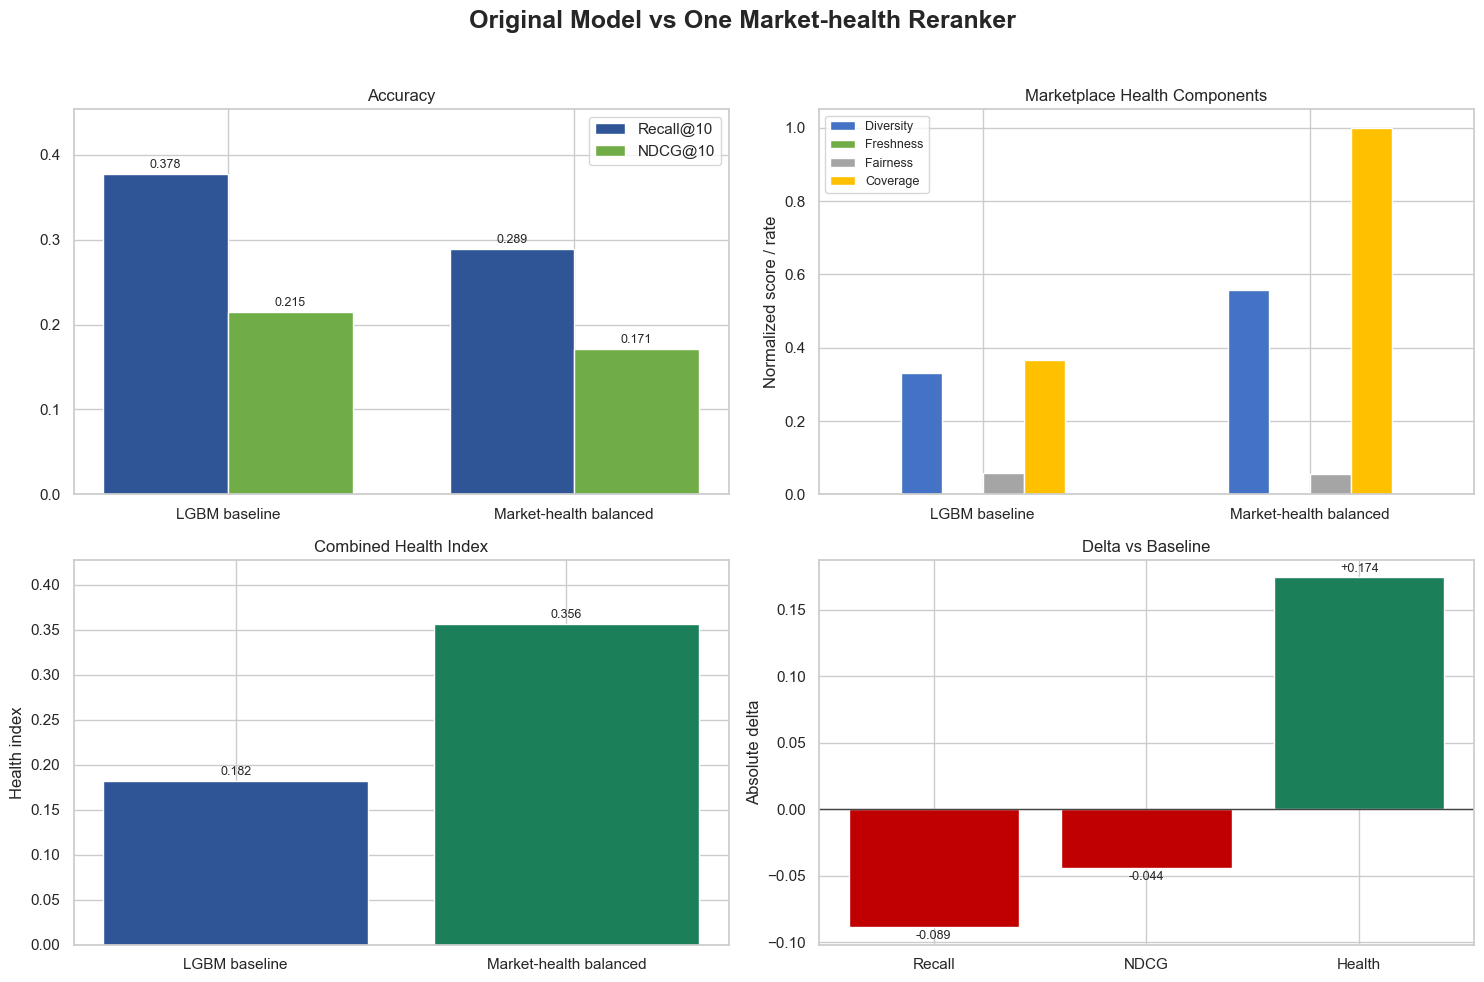

Saved plot: d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\notebooks\outputs\plots\market_health_selected_model_summary.png


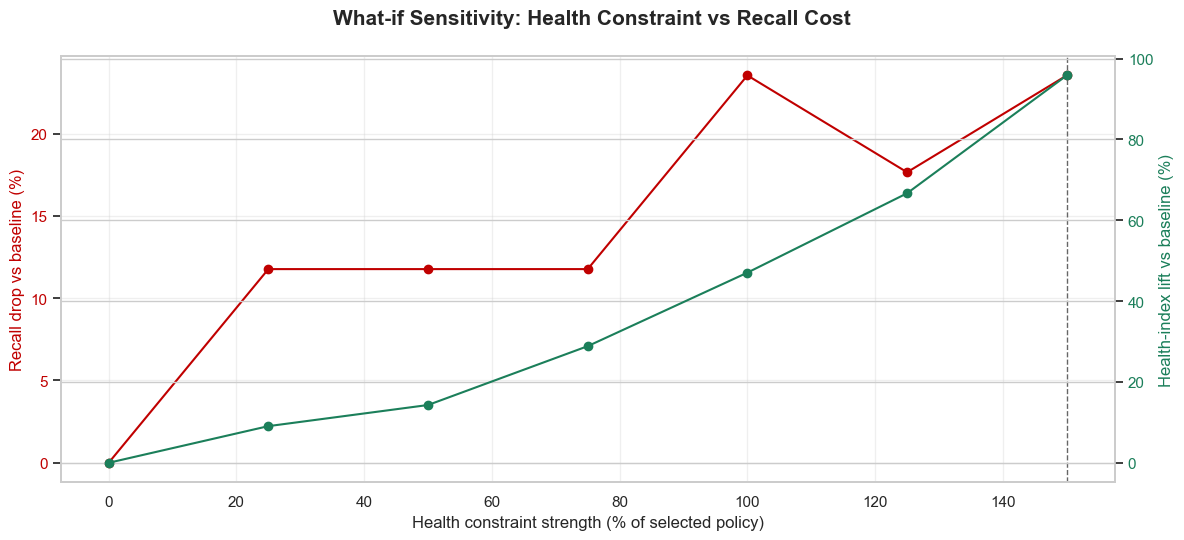

Saved plot: d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\notebooks\outputs\plots\market_health_whatif_recall_cost.png


,health_strength_pct,Recall@10,Recall_drop_abs,Recall_drop_pct,NDCG@10,NDCG_drop_pct,health_index,Health_lift_pct,fresh_14d_rate,unique_category_per_user,seller_gini,catalog_coverage
0,0,0.3778,+0.0000,+0.00%,0.2151,+0.00%,0.182,+0.00%,0.00%,1.39,0.943,0.016%
1,25,0.3333,+0.0444,+11.76%,0.1818,+15.50%,0.198,+9.07%,0.00%,1.46,0.946,0.017%
2,50,0.3333,+0.0444,+11.76%,0.1814,+15.69%,0.208,+14.30%,0.00%,1.53,0.949,0.019%
3,75,0.3333,+0.0444,+11.76%,0.1810,+15.84%,0.234,+28.85%,0.00%,2.02,0.949,0.022%
4,100,0.2889,+0.0889,+23.53%,0.1682,+21.82%,0.267,+47.04%,0.00%,2.58,0.948,0.027%
5,125,0.3111,+0.0667,+17.65%,0.1778,+17.36%,0.303,+66.67%,0.00%,3.29,0.946,0.033%
6,150,0.2889,+0.0889,+23.53%,0.1710,+20.50%,0.356,+95.82%,0.00%,3.84,0.944,0.044%


In [10]:

# Clean plots for the report.
plot_df = health_results.copy()
model_order = plot_df["model"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Original Model vs One Market-health Reranker", fontsize=18, fontweight="bold")

ax = axes[0, 0]
x = np.arange(len(plot_df))
width = 0.36
ax.bar(x - width / 2, plot_df["Recall@10"], width, label="Recall@10", color="#2F5597")
ax.bar(x + width / 2, plot_df["NDCG@10"], width, label="NDCG@10", color="#70AD47")
ax.set_title("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=0)
ax.set_ylim(0, max(plot_df[["Recall@10", "NDCG@10"]].max()) * 1.20 + 1e-9)
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)

ax = axes[0, 1]
component_cols = ["diversity_score", "freshness_score_report", "fairness_score", "coverage_score"]
plot_df.set_index("model")[component_cols].plot(kind="bar", ax=ax, color=["#4472C4", "#70AD47", "#A5A5A5", "#FFC000"])
ax.set_title("Marketplace Health Components")
ax.set_xlabel("")
ax.set_ylabel("Normalized score / rate")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.legend(["Diversity", "Freshness", "Fairness", "Coverage"], fontsize=9)

ax = axes[1, 0]
health_bars = ax.bar(plot_df["model"], plot_df["health_index"], color=["#2F5597", "#1B7F5A"])
ax.set_title("Combined Health Index")
ax.set_ylabel("Health index")
ax.set_ylim(0, max(plot_df["health_index"].max() * 1.20, 0.01))
ax.bar_label(health_bars, fmt="%.3f", fontsize=9, padding=2)

ax = axes[1, 1]
delta_labels = ["Recall", "NDCG", "Health"]
selected = plot_df.loc[plot_df["model"] == "Market-health balanced"].iloc[0]
deltas = [selected["Recall_delta_vs_baseline"], selected["NDCG_delta_vs_baseline"], selected["Health_delta_vs_baseline"]]
colors = ["#C00000" if v < 0 else "#1B7F5A" for v in deltas]
bars = ax.bar(delta_labels, deltas, color=colors)
ax.axhline(0, color="#444444", linewidth=1)
ax.set_title("Delta vs Baseline")
ax.set_ylabel("Absolute delta")
ax.bar_label(bars, fmt="%+.3f", fontsize=9, padding=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
summary_plot_path = os.path.join(PLOT_DIR, "market_health_selected_model_summary.png")
plt.savefig(summary_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved plot: {summary_plot_path}")

# What-if plot: if health pressure changes by X%, how much Recall changes.
fig, ax1 = plt.subplots(figsize=(12, 5.5))
whatif = sensitivity_results.sort_values("health_strength_pct")
ax1.plot(whatif["health_strength_pct"], whatif["Recall_drop_pct"], marker="o", color="#C00000", label="Recall drop vs baseline (%)")
ax1.set_xlabel("Health constraint strength (% of selected policy)")
ax1.set_ylabel("Recall drop vs baseline (%)", color="#C00000")
ax1.tick_params(axis="y", labelcolor="#C00000")
ax1.axvline(selected_strength, color="#666666", linestyle="--", linewidth=1)
ax1.grid(True, alpha=0.30)

ax2 = ax1.twinx()
ax2.plot(whatif["health_strength_pct"], whatif["Health_lift_pct"], marker="o", color="#1B7F5A", label="Health-index lift vs baseline (%)")
ax2.set_ylabel("Health-index lift vs baseline (%)", color="#1B7F5A")
ax2.tick_params(axis="y", labelcolor="#1B7F5A")

fig.suptitle("What-if Sensitivity: Health Constraint vs Recall Cost", fontsize=15, fontweight="bold")
fig.tight_layout()
sensitivity_plot_path = os.path.join(PLOT_DIR, "market_health_whatif_recall_cost.png")
plt.savefig(sensitivity_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved plot: {sensitivity_plot_path}")

sensitivity_results[[
    "health_strength_pct", "Recall@10", "Recall_drop_abs", "Recall_drop_pct",
    "NDCG@10", "NDCG_drop_pct", "health_index", "Health_lift_pct",
    "fresh_14d_rate", "unique_category_per_user", "seller_gini", "catalog_coverage"
]].style.format({
    "Recall@10": "{:.4f}",
    "Recall_drop_abs": "{:+.4f}",
    "Recall_drop_pct": "{:+.2f}%",
    "NDCG@10": "{:.4f}",
    "NDCG_drop_pct": "{:+.2f}%",
    "health_index": "{:.3f}",
    "Health_lift_pct": "{:+.2f}%",
    "fresh_14d_rate": "{:.2%}",
    "unique_category_per_user": "{:.2f}",
    "seller_gini": "{:.3f}",
    "catalog_coverage": "{:.3%}",
})


## 5) Report Notes

Suggested wording for the report:

- The original LightGBM ranker is kept as the accuracy baseline.
- A single market-health reranker is applied after scoring, so the core model and candidate pipeline are unchanged.
- The reranker is selected with an accuracy guardrail: maximize health index while keeping Recall loss small.
- The what-if table answers the trade-off question directly: when health constraint strength increases by X%, Recall drops by Y% and health index changes by Z%.
- In production, these weights should be tuned by A/B testing with monitoring for Contact Rate, Recall/NDCG, fresh listing exposure, seller concentration, private/agent exposure, diversity, and catalog coverage.
